# Сверточные графовые сети

In [1]:
!pip install torch_geometric networkx

In [ ]:
import torch_geometric
from torch_geometric.datasets import Planetoid
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

In [ ]:
dataset = Planetoid(root=".", name="Cora")
data = dataset[0]
g = torch_geometric.utils.to_networkx(data, to_undirected=True)
nx.draw(g,node_size=3,width=0.1)

In [1]:
print(data.x.shape)

NameError: name 'data' is not defined

In [3]:
print(data.y.shape)
print(data.y)
print(np.unique(data.y))

torch.Size([2708])
tensor([3, 4, 4,  ..., 3, 3, 3])
[0 1 2 3 4 5 6]


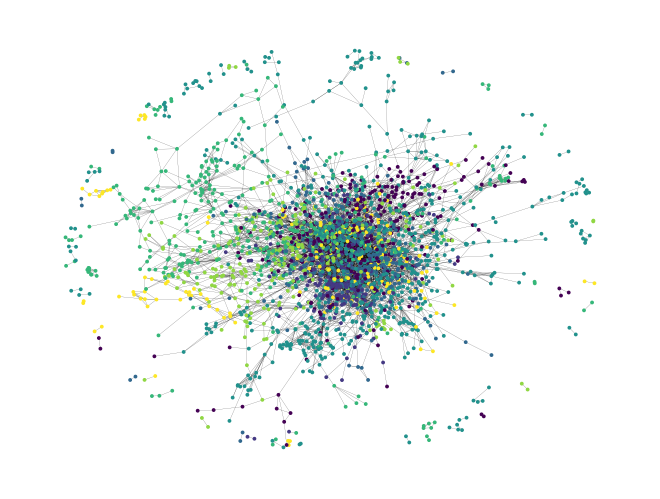

In [4]:
nx.draw(g,node_size=3,node_color=data.y,width=0.1)

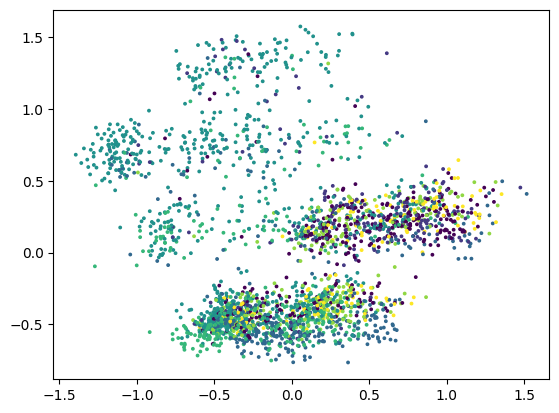

In [5]:
from sklearn.decomposition import PCA
tr=PCA(n_components=2)
x1=tr.fit_transform(data.x)
plt.scatter(x1[:,0],x1[:,1],c=data.y,s=3)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
Xtr,Xt,Ytr,Yt=train_test_split(data.x,data.y)
clf=RandomForestClassifier()
clf.fit(Xtr,Ytr)
clf.score(Xt,Yt)

0.7769571639586411

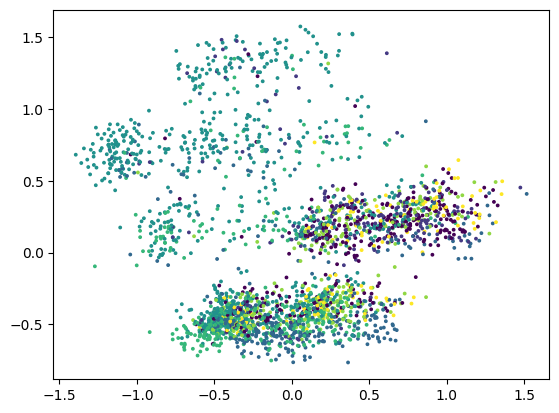

In [8]:
plt.scatter(x1[:,0],x1[:,1],c=clf.predict(data.x),s=3)

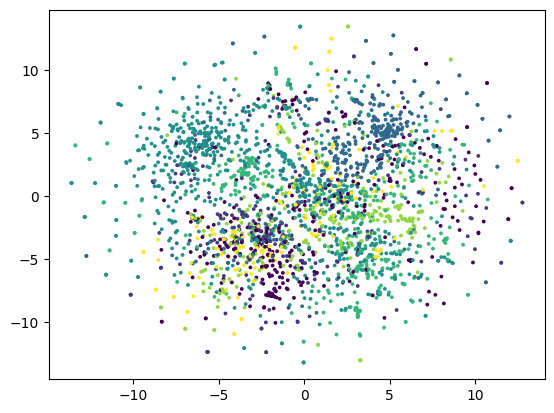

In [29]:
from sklearn.manifold import TSNE
tr=TSNE(n_components=2)
x2=tr.fit_transform(data.x)
plt.scatter(x2[:,0],x2[:,1],c=data.y,s=3)

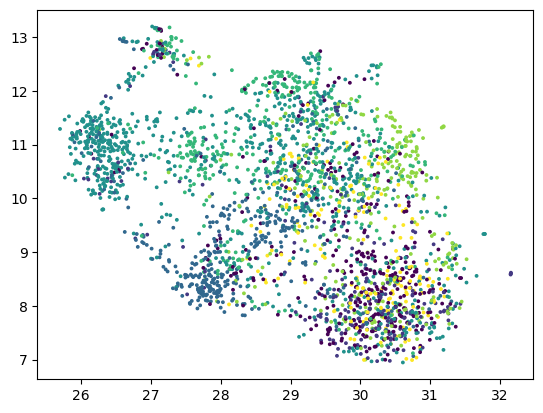

In [30]:
from umap.umap_ import UMAP
tr=UMAP(n_components=2)
x3=tr.fit_transform(data.x)
plt.scatter(x3[:,0],x3[:,1],c=data.y,s=3)

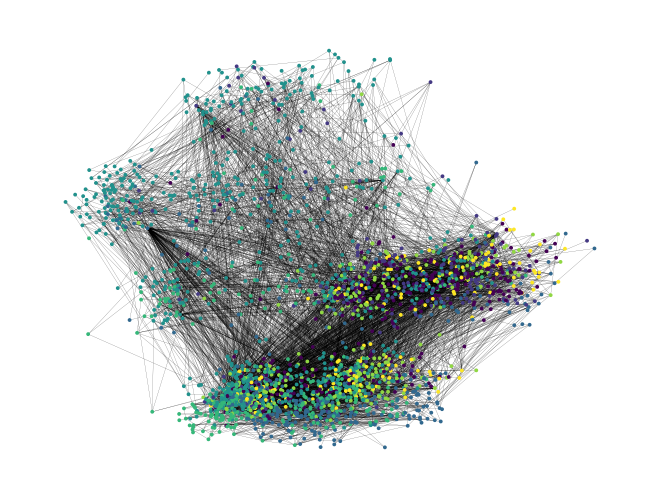

In [37]:
pos=x1
nx.draw(g,pos,node_color=data.y,node_size=3,width=0.1)

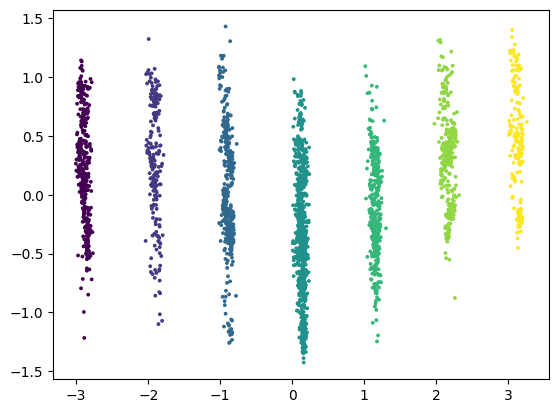

In [9]:
tr=PCA(n_components=2)
x4=tr.fit_transform(np.concatenate([data.x,data.y[:,np.newaxis]],axis=-1))
plt.scatter(x4[:,0],x4[:,1],c=data.y,s=3)

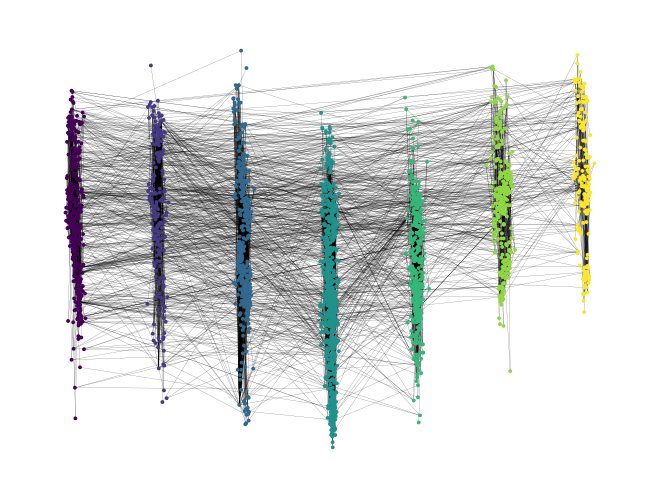

In [10]:
pos=x4
nx.draw(g,pos,node_color=data.y,node_size=3,width=0.1)

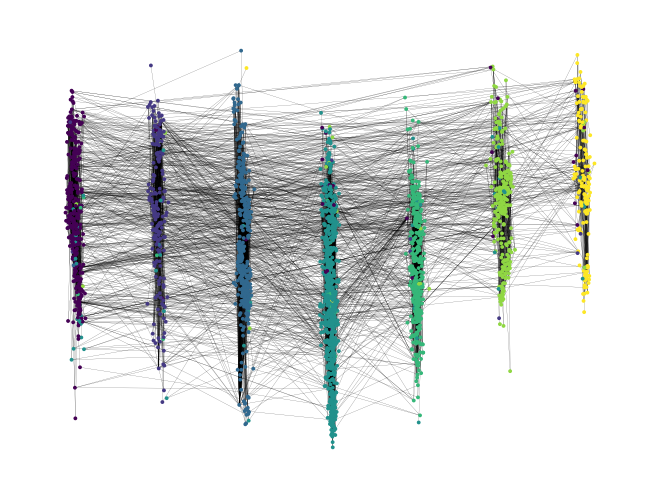

In [11]:
pos=x4
nx.draw(g,pos,node_color=clf.predict(data.x),node_size=3,width=0.1)

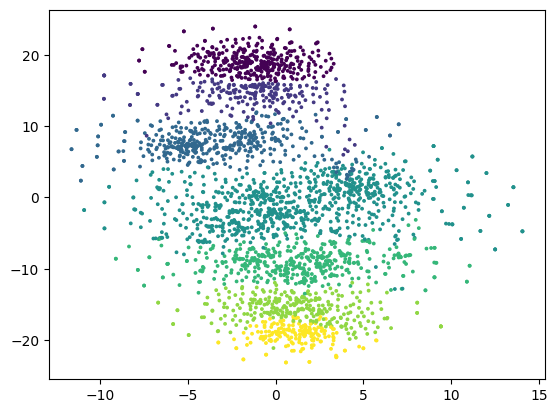

In [43]:
from sklearn.manifold import TSNE
tr=TSNE(n_components=2)
x5=tr.fit_transform(np.concatenate([data.x,data.y[:,np.newaxis]],axis=-1))
plt.scatter(x5[:,0],x5[:,1],c=data.y,s=3)

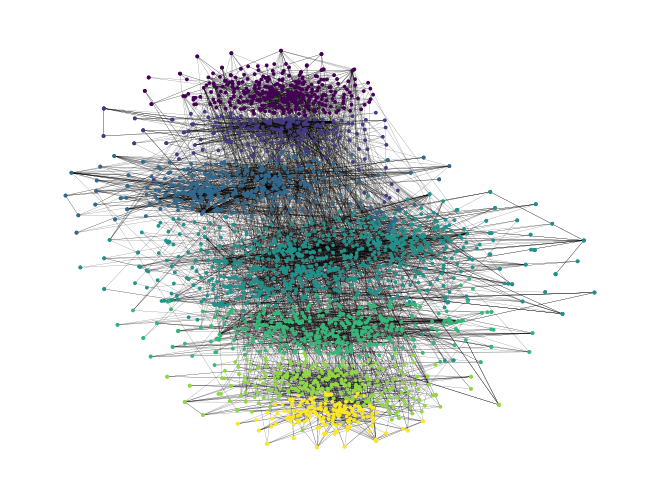

In [44]:
nx.draw(g,x5,node_color=data.y,node_size=3,width=0.1)